In [3]:
import pandas as pd

'''添加上映年份列'''

df = pd.read_csv('D:\\VSProject\\career-ai\\movies_info_200.csv')

# 获取上映年份
df['上映年份'] = df['上映日期'].astype(str).str.extract(r'(\d{4})')[0]

# 直接写回原文件，覆盖原 CSV
df.to_csv('D:\\VSProject\\career-ai\\movies_info_200.csv', index=False, encoding='utf-8')


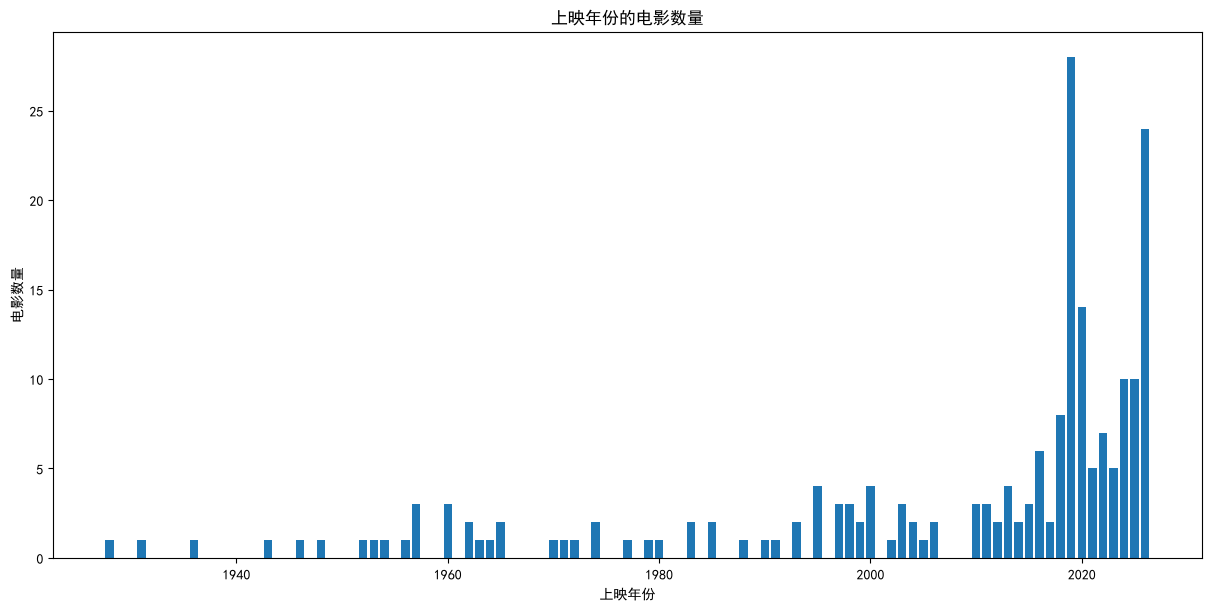

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
'''统计不同年份的电影数量对比'''
# 设置中文
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
df = pd.read_csv('D:\\VSProject\\career-ai\\movies_info_200.csv')
# 统计top200上映年份的电影数量
year_counts = df.groupby('上映年份')['上映年份'].count()

x=year_counts.index
y=year_counts.values
# 创建画布：宽 12 英寸、高 6 英寸，并自动调整布局
plt.figure(figsize=(12, 6), constrained_layout=True)
plt.bar(x, y)
plt.xlabel('上映年份')
plt.ylabel('电影数量')
plt.title('上映年份的电影数量')
plt.show()

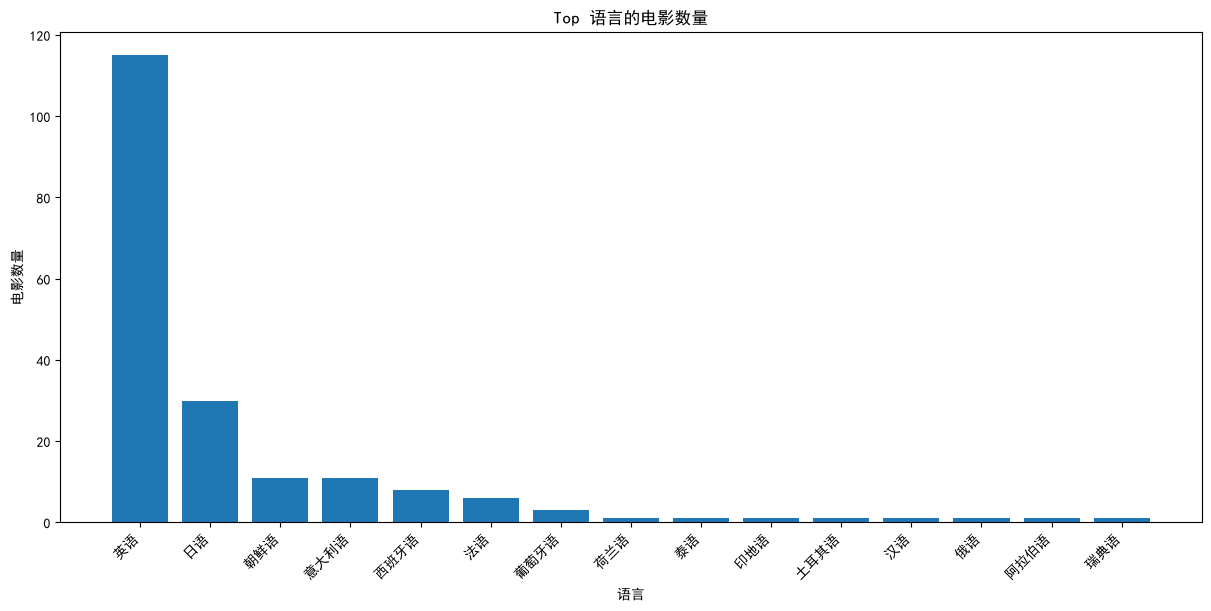

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
'''统计不同语言的电影数量对比'''
# 设置中文
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('D:\\VSProject\\career-ai\\movies_info_200.csv')

# 去除首尾空格，并将包含数字、$、占位符“-”等非语言名称的值设为缺失
language = df['语言']
valid = language.str.replace(r'\s+', '', regex=True).str.isalpha().fillna(False)

df['语言'] = language.where(valid, pd.NA)

# 统计有效语言的电影数量
language_counts = df['语言'].value_counts().sort_values(ascending=False)
x=language_counts.index
y=language_counts.values

# 创建画布：宽 12 英寸、高 6 英寸，并自动调整布局
plt.figure(figsize=(12, 6), constrained_layout=True)
# 根据 x（语言）和 y（电影数量）绘制柱状图
plt.bar(x, y)
# 将 x 轴标签旋转 45 度并右对齐，减少文字重叠
plt.xticks(rotation=45, ha='right')

plt.xlabel('语言')
plt.ylabel('电影数量')
plt.title('Top 语言的电影数量')
plt.show()


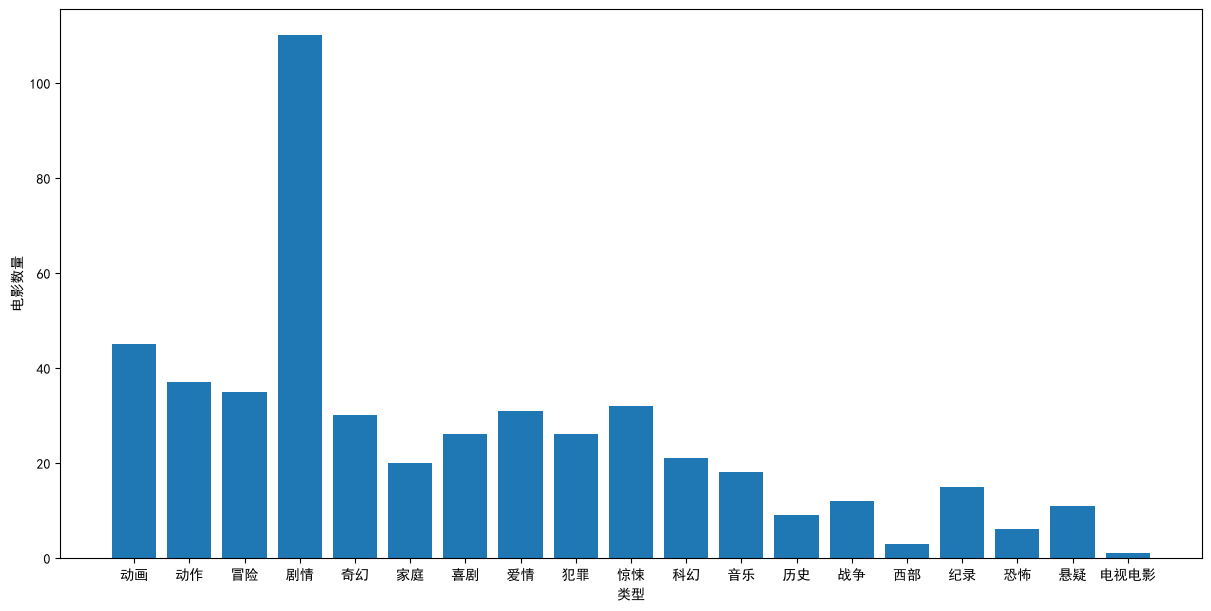

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
'''统计不同类型电影数量对比'''
# 设置中文
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('D:\\VSProject\\career-ai\\movies_info_200.csv')

type_count={}
for types in df['类型'].dropna().astype(str).str.split(','):
    # 判断每个类型是否已经在字典中，如果在则计数加1，否则初始化为1
    for type in types:
        if type in type_count:  
            type_count[type] += 1
        else: 
            type_count[type] = 1
x= list(type_count.keys())
y= list(type_count.values())

# 创建画布：宽 12 英寸、高 6 英寸，并自动调整布局
plt.figure(figsize=(12, 6), constrained_layout=True)
# 根据 x（语言）和 y（电影数量）绘制柱状图
plt.bar(x, y)

plt.xlabel('类型')
plt.ylabel('电影数量')
plt.show()

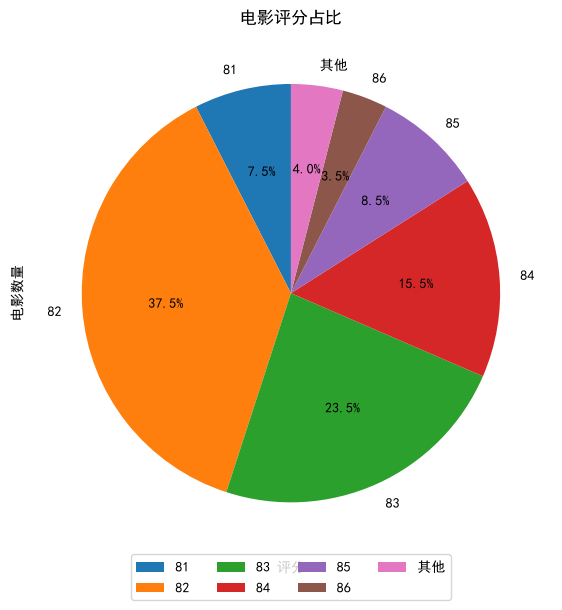

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
'''统计电影评分占比'''
# 设置中文
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('D:\\VSProject\\career-ai\\movies_info_200.csv')

score_counts = df.groupby('评分')['评分'].count()
# 合并小数据（比例小于2%的评分）
total = score_counts.sum()
large_scores = score_counts.loc[score_counts/total >= 0.02]
small_scores = score_counts.loc[score_counts/total < 0.02]
if small_scores.shape[0] > 0:
  large_scores = pd.concat([large_scores, pd.Series({'其他': small_scores.sum()})])


# 将评分和对应的数量转换为列表
scores = large_scores.index.tolist()
scores_values = large_scores.values.tolist()

# 创建画布：宽 12 英寸、高 6 英寸，并自动调整布局
plt.figure(figsize=(12, 6), constrained_layout=True)
plt.pie(scores_values, labels=scores, autopct='%1.1f%%',startangle=90)
plt.xlabel('评分')
plt.ylabel('电影数量')
plt.title('电影评分占比')
plt.legend(loc='lower center',ncol=4, bbox_to_anchor=(0.5, -0.1))
plt.show()